In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import json
import math
import random

from collections import defaultdict
from itertools import product

# 1 Load Data

In [2]:
data_dir = "../data/1mil"

ratings_path = f"{data_dir}/ratings.dat"
movies_path = f"{data_dir}/movies.dat"
users_path = f"{data_dir}/users.dat"

ratings = pd.read_csv(
    ratings_path,
    sep="::",
    engine="python",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

movies = pd.read_csv(
    movies_path,
    sep="::",
    engine="python",
    names=["movie_id", "title", "genres"],
    encoding="latin-1"
)

users = pd.read_csv(
    users_path,
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip_code"]
)

# 2 Data Exploration

In [3]:
print("Ratings:")
display(ratings.head())

print("Movies:")
display(movies.head())

print("Users:")
display(users.head())

Ratings:


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


Movies:


,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


Users:


,user_id,gender,age,occupation,zip_code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [4]:
print("Shapes")
print("ratings:", ratings.shape)
print("movies: ", movies.shape)
print("users:  ", users.shape)

print("\nMissing values")
print("\nRatings Data\n", ratings.isna().sum())
print("\nMovies Data\n", movies.isna().sum())
print("\nUsers Data\n", users.isna().sum())

print("\nDuplicates")
print("ratings:", ratings.duplicated().sum())
print("movies: ", movies.duplicated().sum())
print("users:  ", users.duplicated().sum())

print("\nRating values:")
print(sorted(ratings["rating"].unique()))

print("\nConsistency")
print(
    "All user_id in ratings exist in users:",
    ratings["user_id"].isin(users["user_id"]).all()
)
print(
    "All movie_id in ratings exist in movies:",
    ratings["movie_id"].isin(movies["movie_id"]).all()
)

Shapes
ratings: (1000209, 4)
movies:  (3883, 3)
users:   (6040, 5)

Missing values

Ratings Data
 user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Movies Data
 movie_id    0
title       0
genres      0
dtype: int64

Users Data
 user_id       0
gender        0
age           0
occupation    0
zip_code      0
dtype: int64

Duplicates
ratings: 0
movies:  0
users:   0

Rating values:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Consistency
All user_id in ratings exist in users: True
All movie_id in ratings exist in movies: True


### Add Datetime
We convert Unix timestamps to datetime values. The original timestamp is preserved because it is still useful for pairwise records and overlap checks.

In [5]:
ratings = ratings.copy()
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s")

ratings.head()

,user_id,movie_id,rating,timestamp,datetime
0,1,1193,5,978300760,2000-12-31 22:12:40
1,1,661,3,978302109,2000-12-31 22:35:09
2,1,914,3,978301968,2000-12-31 22:32:48
3,1,3408,4,978300275,2000-12-31 22:04:35
4,1,2355,5,978824291,2001-01-06 23:38:11


### Ratings Distribution

We inspect the global rating distribution before pairwise construction.

This is important because the number and type of pairwise comparisons depend heavily on how ratings are distributed. If most ratings are concentrated around 3 and 4 stars, then many pairs will be ties or near-ties, and strong preferences will be less frequent.

,rating,count,share
0,1,56174,0.0562
1,2,107557,0.1075
2,3,261197,0.2611
3,4,348971,0.3489
4,5,226310,0.2263


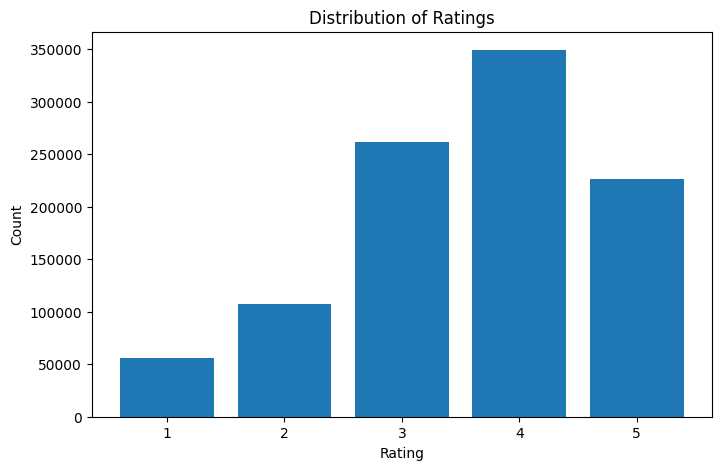

In [6]:
rating_dist = (
    ratings["rating"]
    .value_counts()
    .sort_index()
    .rename_axis("rating")
    .reset_index(name="count")
)

rating_dist["share"] = (rating_dist["count"] / rating_dist["count"].sum()).round(4)

display(rating_dist)

plt.figure(figsize=(8, 5))
plt.bar(rating_dist["rating"].astype(str), rating_dist["count"])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of Ratings")
plt.show()

### User Analysis
We inspect how many ratings each user has. This helps us decide whether to remove extremely sparse users.

Sparse users provide few pairwise preferences and may make user embeddings unstable. However, removing them also reduces user coverage and may affect fairness, especially for casual users.

In [7]:
user_activity = ratings.groupby("user_id").size()

print("User activity describe:")
display(user_activity.describe())

User activity describe:


count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
dtype: float64

In [8]:
user_thresholds = [20, 30, 40, 50, 100]

rows = []

for t in user_thresholds:
    kept_user_ids = user_activity[user_activity >= t].index
    filtered = ratings[ratings["user_id"].isin(kept_user_ids)]

    filtered_user_activity = filtered.groupby("user_id").size()

    rows.append({
        "min_user_ratings": t,
        "users_kept": filtered["user_id"].nunique(),
        "movies_kept": filtered["movie_id"].nunique(),
        "ratings_kept": len(filtered),

        "share_users_kept": round(
            filtered["user_id"].nunique() / ratings["user_id"].nunique(),
            4,
        ),
        "share_movies_kept": round(
            filtered["movie_id"].nunique() / ratings["movie_id"].nunique(),
            4,
        ),
        "share_ratings_kept": round(len(filtered) / len(ratings), 4),

        "avg_ratings_per_user": round(
            len(filtered) / filtered["user_id"].nunique(),
            2,
        ),
        "median_ratings_per_user": round(
            filtered_user_activity.median(),
            2,
        ),
    })

user_threshold_effect = pd.DataFrame(rows)
display(user_threshold_effect)

,min_user_ratings,users_kept,movies_kept,ratings_kept,share_users_kept,share_movies_kept,share_ratings_kept,avg_ratings_per_user,median_ratings_per_user
0,20,6040,3706,1000209,1.0000,1.0000,1.0000,165.60,96.0
1,30,5289,3701,982040,0.8757,0.9987,0.9818,185.68,114.0
2,40,4737,3694,963023,0.7843,0.9968,0.9628,203.30,129.0
3,50,4297,3689,943471,0.7114,0.9954,0.9433,219.57,146.0
4,100,2945,3670,847302,0.4876,0.9903,0.8471,287.71,212.0


### Movie Analysis
We also inspect how many ratings each movie has.

Very infrequently rated movies may have unstable item embeddings and can increase item cold-start issues. At the same time, removing too many movies reduces catalog coverage.

In [9]:
movie_activity = ratings.groupby("movie_id").size()

print("Movie activity describe:")
display(movie_activity.describe())

Movie activity describe:


count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
dtype: float64

In [10]:
movie_thresholds = [1, 5, 10, 20, 40, 100]

rows = []

for t in movie_thresholds:
    kept_movie_ids = movie_activity[movie_activity >= t].index
    filtered = ratings[ratings["movie_id"].isin(kept_movie_ids)]

    filtered_movie_activity = filtered.groupby("movie_id").size()

    rows.append({
        "min_movie_ratings": t,
        "movies_kept": filtered["movie_id"].nunique(),
        "users_kept": filtered["user_id"].nunique(),
        "ratings_kept": len(filtered),

        "share_movies_kept": round(
            filtered["movie_id"].nunique() / ratings["movie_id"].nunique(),
            4,
        ),
        "share_users_kept": round(
            filtered["user_id"].nunique() / ratings["user_id"].nunique(),
            4,
        ),
        "share_ratings_kept": round(len(filtered) / len(ratings), 4),

        "avg_ratings_per_movie": round(
            len(filtered) / filtered["movie_id"].nunique(),
            2,
        ),
        "median_ratings_per_movie": round(
            filtered_movie_activity.median(),
            2,
        ),
    })

movie_threshold_effect = pd.DataFrame(rows)
display(movie_threshold_effect)

,min_movie_ratings,movies_kept,users_kept,ratings_kept,share_movies_kept,share_users_kept,share_ratings_kept,avg_ratings_per_movie,median_ratings_per_movie
0,1,3706,6040,1000209,1.0000,1.0,1.0000,269.89,123.5
1,5,3416,6040,999611,0.9217,1.0,0.9994,292.63,146.0
2,10,3260,6040,998539,0.8797,1.0,0.9983,306.30,161.0
3,20,3043,6040,995492,0.8211,1.0,0.9953,327.14,180.0
4,40,2673,6040,984878,0.7213,1.0,0.9847,368.45,219.0
5,100,2019,6040,942225,0.5448,1.0,0.9420,466.68,314.0


### Tie Analysis

Pairwise preferences are generated from rated items of the same user.

For a user, if two items have the same rating, we treat the comparison as a tie. If their rating difference is 1 star, we treat it as a near-tie or weak preference.

For this project, we use only strong pairwise preferences:

\[
rating_i - rating_j \geq 2
\]

This means:

- exact ties are removed
- one-star differences are removed as uncertain
- only clearer preferences are kept

This makes the pairwise signal cleaner for BPR and downstream pairwise classifiers, but it also narrows the task to strong preferences only.

In [11]:
rows = []

for user_id, group in ratings.groupby("user_id"):
    rating_counts = group["rating"].value_counts().to_dict()

    c1 = rating_counts.get(1, 0)
    c2 = rating_counts.get(2, 0)
    c3 = rating_counts.get(3, 0)
    c4 = rating_counts.get(4, 0)
    c5 = rating_counts.get(5, 0)

    n = len(group)

    total_pairs = math.comb(n, 2)

    tie_pairs = (
        math.comb(c1, 2) +
        math.comb(c2, 2) +
        math.comb(c3, 2) +
        math.comb(c4, 2) +
        math.comb(c5, 2)
    )

    near_tie_pairs = (
        c1 * c2 +
        c2 * c3 +
        c3 * c4 +
        c4 * c5
    )

    strong_pref_pairs = total_pairs - tie_pairs - near_tie_pairs
    non_equal_pairs = total_pairs - tie_pairs

    rows.append({
        "user_id": user_id,
        "items_rated": n,
        "total_pairs": total_pairs,
        "tie_pairs": tie_pairs,
        "near_tie_pairs": near_tie_pairs,
        "strong_pref_pairs": strong_pref_pairs,
        "non_equal_pairs": non_equal_pairs,
    })

tie_analysis_per_user = pd.DataFrame(rows)
display(tie_analysis_per_user.head())

,user_id,items_rated,total_pairs,tie_pairs,near_tie_pairs,strong_pref_pairs,non_equal_pairs
0,1,53,1378,532,702,144,846
1,2,129,8256,2261,3498,2497,5995
2,3,51,1275,378,568,329,897
3,4,21,210,73,90,47,137
4,5,198,19503,4671,7882,6950,14832


In [12]:
tie_summary = pd.DataFrame([{
    "users": tie_analysis_per_user["user_id"].nunique(),
    "total_pairs": tie_analysis_per_user["total_pairs"].sum(),
    "tie_pairs": tie_analysis_per_user["tie_pairs"].sum(),
    "near_tie_pairs": tie_analysis_per_user["near_tie_pairs"].sum(),
    "strong_pref_pairs": tie_analysis_per_user["strong_pref_pairs"].sum(),
    "non_equal_pairs": tie_analysis_per_user["non_equal_pairs"].sum(),
}])

tie_summary["tie_share"] = round(
    tie_summary["tie_pairs"] / tie_summary["total_pairs"],
    4,
)
tie_summary["near_tie_share"] = round(
    tie_summary["near_tie_pairs"] / tie_summary["total_pairs"],
    4,
)
tie_summary["strong_pref_share"] = round(
    tie_summary["strong_pref_pairs"] / tie_summary["total_pairs"],
    4,
)
tie_summary["non_equal_share"] = round(
    tie_summary["non_equal_pairs"] / tie_summary["total_pairs"],
    4,
)

display(tie_summary)

,users,total_pairs,tie_pairs,near_tie_pairs,strong_pref_pairs,non_equal_pairs,tie_share,near_tie_share,strong_pref_share,non_equal_share
0,6040,194494663,57371886,80774336,56348441,137122777,0.295,0.4153,0.2897,0.705


In [13]:
policy_summary = pd.DataFrame([
    {
        "policy": "diff >= 1",
        "pairs_kept": tie_analysis_per_user["non_equal_pairs"].sum(),
        "avg_pairs_per_user": round(
            tie_analysis_per_user["non_equal_pairs"].mean(),
            2,
        ),
        "median_pairs_per_user": round(
            tie_analysis_per_user["non_equal_pairs"].median(),
            2,
        ),
        "users_with_zero_pairs": int(
            (tie_analysis_per_user["non_equal_pairs"] == 0).sum()
        ),
        "users_with_less_than_10_pairs": int(
            (tie_analysis_per_user["non_equal_pairs"] < 10).sum()
        ),
        "users_with_less_than_50_pairs": int(
            (tie_analysis_per_user["non_equal_pairs"] < 50).sum()
        ),
    },
    {
        "policy": "diff >= 2",
        "pairs_kept": tie_analysis_per_user["strong_pref_pairs"].sum(),
        "avg_pairs_per_user": round(
            tie_analysis_per_user["strong_pref_pairs"].mean(),
            2,
        ),
        "median_pairs_per_user": round(
            tie_analysis_per_user["strong_pref_pairs"].median(),
            2,
        ),
        "users_with_zero_pairs": int(
            (tie_analysis_per_user["strong_pref_pairs"] == 0).sum()
        ),
        "users_with_less_than_10_pairs": int(
            (tie_analysis_per_user["strong_pref_pairs"] < 10).sum()
        ),
        "users_with_less_than_50_pairs": int(
            (tie_analysis_per_user["strong_pref_pairs"] < 50).sum()
        ),
    },
])

policy_summary["share_pairs_kept"] = round(
    policy_summary["pairs_kept"] / tie_analysis_per_user["total_pairs"].sum(),
    4,
)

display(policy_summary)

,policy,pairs_kept,avg_pairs_per_user,median_pairs_per_user,users_with_zero_pairs,users_with_less_than_10_pairs,users_with_less_than_50_pairs,share_pairs_kept
0,diff >= 1,137122777,22702.45,3071.0,0,0,4,0.7050
1,diff >= 2,56348441,9329.21,1102.0,11,15,191,0.2897


# 3 Filtering

We apply iterative joint filtering with the following thresholds:

- minimum user ratings: 40
- minimum movie ratings: 10

Filtering is iterative because removing low-activity users can reduce movie frequencies, and removing infrequent movies can in turn reduce some users below the user threshold.

This filtering step is performed before temporal splitting. It should be understood as a dataset preprocessing choice: we define a sufficiently dense analysis population first, and then evaluate models temporally within that population.

This improves pairwise signal reliability but reduces representation of low-activity users, which is a potential fairness and generalizability limitation.

In [14]:
min_user_ratings = 40
min_movie_ratings = 10

In [15]:
def iterative_joint_filter(
    ratings_df,
    min_user_ratings,
    min_movie_ratings,
):
    ratings_filtered = ratings_df.copy()

    while True:
        prev_users = set(ratings_filtered["user_id"].unique())
        prev_movies = set(ratings_filtered["movie_id"].unique())

        user_activity = ratings_filtered.groupby("user_id").size()
        valid_users = user_activity[user_activity >= min_user_ratings].index
        ratings_filtered = ratings_filtered[
            ratings_filtered["user_id"].isin(valid_users)
        ].copy()

        movie_activity = ratings_filtered.groupby("movie_id").size()
        valid_movies = movie_activity[movie_activity >= min_movie_ratings].index
        ratings_filtered = ratings_filtered[
            ratings_filtered["movie_id"].isin(valid_movies)
        ].copy()

        new_users = set(ratings_filtered["user_id"].unique())
        new_movies = set(ratings_filtered["movie_id"].unique())

        if new_users == prev_users and new_movies == prev_movies:
            break

    return ratings_filtered.reset_index(drop=True)


ratings_filtered = iterative_joint_filter(
    ratings,
    min_user_ratings=min_user_ratings,
    min_movie_ratings=min_movie_ratings,
)

In [16]:
filtering_summary = pd.DataFrame([{
    "min_user_ratings": min_user_ratings,
    "min_movie_ratings": min_movie_ratings,
    "ratings_kept": len(ratings_filtered),
    "users_kept": ratings_filtered["user_id"].nunique(),
    "movies_kept": ratings_filtered["movie_id"].nunique(),
    "share_ratings_kept": round(len(ratings_filtered) / len(ratings), 4),
    "share_users_kept": round(
        ratings_filtered["user_id"].nunique() / ratings["user_id"].nunique(),
        4,
    ),
    "share_movies_kept": round(
        ratings_filtered["movie_id"].nunique() / ratings["movie_id"].nunique(),
        4,
    ),
    "avg_ratings_per_user": round(
        ratings_filtered.groupby("user_id").size().mean(),
        2,
    ),
    "median_ratings_per_user": round(
        ratings_filtered.groupby("user_id").size().median(),
        2,
    ),
    "avg_ratings_per_movie": round(
        ratings_filtered.groupby("movie_id").size().mean(),
        2,
    ),
    "median_ratings_per_movie": round(
        ratings_filtered.groupby("movie_id").size().median(),
        2,
    ),
}])

display(filtering_summary)

,min_user_ratings,min_movie_ratings,ratings_kept,users_kept,movies_kept,share_ratings_kept,share_users_kept,share_movies_kept,avg_ratings_per_user,median_ratings_per_user,avg_ratings_per_movie,median_ratings_per_movie
0,40,10,960916,4726,3250,0.9607,0.7825,0.877,203.33,129.0,295.67,158.0


In [17]:
final_user_counts = ratings_filtered.groupby("user_id").size()
final_movie_counts = ratings_filtered.groupby("movie_id").size()

print(
    "All users satisfy min_user_ratings:",
    (final_user_counts >= min_user_ratings).all(),
)
print(
    "All movies satisfy min_movie_ratings:",
    (final_movie_counts >= min_movie_ratings).all(),
)

All users satisfy min_user_ratings: True
All movies satisfy min_movie_ratings: True


### Demographic Retention Check

Since filtering removes low-activity users, we check whether the retained user population differs by available demographic attributes.

This does not solve fairness concerns by itself, but it documents whether filtering disproportionately removes some user groups.

In [18]:
raw_user_ids = set(ratings["user_id"].unique())
filtered_user_ids = set(ratings_filtered["user_id"].unique())

user_retention = users.copy()
user_retention["in_raw_ratings"] = user_retention["user_id"].isin(raw_user_ids)
user_retention["retained_after_filtering"] = user_retention["user_id"].isin(
    filtered_user_ids
)

gender_retention = (
    user_retention[user_retention["in_raw_ratings"]]
    .groupby("gender")["retained_after_filtering"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "users_raw",
        "sum": "users_retained",
        "mean": "retention_rate",
    })
)

gender_retention["retention_rate"] = gender_retention["retention_rate"].round(4)

age_retention = (
    user_retention[user_retention["in_raw_ratings"]]
    .groupby("age")["retained_after_filtering"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "users_raw",
        "sum": "users_retained",
        "mean": "retention_rate",
    })
)

age_retention["retention_rate"] = age_retention["retention_rate"].round(4)

print("Gender retention:")
display(gender_retention)

print("Age retention:")
display(age_retention)

Gender retention:


,gender,users_raw,users_retained,retention_rate
0,F,1709,1276,0.7466
1,M,4331,3450,0.7966


Age retention:


,age,users_raw,users_retained,retention_rate
0,1,222,172,0.7748
1,18,1103,860,0.7797
2,25,2096,1694,0.8082
3,35,1193,932,0.7812
4,45,550,424,0.7709
5,50,496,381,0.7681
6,56,380,263,0.6921


In [19]:
# Occupation retention after interaction-level filtering

occupation_retention = (
    user_retention[user_retention["in_raw_ratings"]]
    .groupby("occupation")["retained_after_filtering"]
    .agg(["count", "sum", "mean"])
    .reset_index()
    .rename(columns={
        "count": "users_raw",
        "sum": "users_retained",
        "mean": "retention_rate",
    })
)

occupation_retention["retention_rate"] = occupation_retention["retention_rate"].round(4)

print("Occupation retention:")
display(occupation_retention.sort_values("retention_rate"))

Occupation retention:


,occupation,users_raw,users_retained,retention_rate
8,8,17,11,0.6471
6,6,236,163,0.6907
13,13,142,100,0.7042
9,9,92,67,0.7283
7,7,679,515,0.7585
1,1,528,407,0.7708
17,17,502,387,0.7709
18,18,70,54,0.7714
2,2,267,208,0.7790
14,14,302,236,0.7815


# 4 Train / Validation / Test Split

We use a per-user temporal split.

For each user:

- the most recent timestamp blocks are assigned to the test set
- the previous timestamp blocks are assigned to the validation set
- earlier interactions are assigned to the training set

Interactions with the same timestamp for the same user are kept in the same split. This avoids breaking timestamp groups across train, validation, and test.

To avoid item cold-start during pairwise evaluation, validation and test interactions are restricted to movies that appear in the training split.

After this, we keep only users that still have records in all three splits.

In [20]:
def summarize_interaction_split(df, split_name, stage):
    if len(df) == 0:
        return {
            "stage": stage,
            "split": split_name,
            "rows": 0,
            "users": 0,
            "movies": 0,
        }

    return {
        "stage": stage,
        "split": split_name,
        "rows": len(df),
        "users": df["user_id"].nunique(),
        "movies": df["movie_id"].nunique(),
    }


def temporal_split_by_timestamp_groups_strict(
    df,
    val_ratio=0.1,
    test_ratio=0.1,
):
    train_parts = []
    val_parts = []
    test_parts = []

    for user_id, user_df in df.groupby("user_id"):
        user_df = user_df.sort_values(["datetime", "movie_id"]).copy()

        time_blocks = [
            block
            for _, block in user_df.groupby("datetime", sort=True)
        ]

        n_ratings = len(user_df)
        target_test = max(1, int(round(n_ratings * test_ratio)))
        target_val = max(1, int(round(n_ratings * val_ratio)))

        test_blocks = []
        test_count = 0
        i = len(time_blocks) - 1

        while i >= 0 and test_count < target_test:
            test_blocks.append(time_blocks[i])
            test_count += len(time_blocks[i])
            i -= 1

        val_blocks = []
        val_count = 0

        while i >= 0 and val_count < target_val:
            val_blocks.append(time_blocks[i])
            val_count += len(time_blocks[i])
            i -= 1

        train_blocks = time_blocks[:i + 1]

        if len(train_blocks) == 0 or len(val_blocks) == 0 or len(test_blocks) == 0:
            continue

        train_user = pd.concat(train_blocks, ignore_index=True)
        val_user = pd.concat(val_blocks[::-1], ignore_index=True)
        test_user = pd.concat(test_blocks[::-1], ignore_index=True)

        train_parts.append(train_user)
        val_parts.append(val_user)
        test_parts.append(test_user)

    train_df = pd.concat(train_parts, ignore_index=True)
    val_df = pd.concat(val_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    train_df = train_df.sort_values(
        ["user_id", "datetime", "movie_id"]
    ).reset_index(drop=True)
    val_df = val_df.sort_values(
        ["user_id", "datetime", "movie_id"]
    ).reset_index(drop=True)
    test_df = test_df.sort_values(
        ["user_id", "datetime", "movie_id"]
    ).reset_index(drop=True)

    processing_rows = []

    for split_name, split_df in [
        ("train", train_df),
        ("validation", val_df),
        ("test", test_df),
    ]:
        processing_rows.append(
            summarize_interaction_split(
                split_df,
                split_name,
                "before_item_cold_start_filter",
            )
        )

    train_movies = set(train_df["movie_id"].unique())

    val_df = val_df[val_df["movie_id"].isin(train_movies)].copy()
    test_df = test_df[test_df["movie_id"].isin(train_movies)].copy()

    for split_name, split_df in [
        ("train", train_df),
        ("validation", val_df),
        ("test", test_df),
    ]:
        processing_rows.append(
            summarize_interaction_split(
                split_df,
                split_name,
                "after_item_cold_start_filter",
            )
        )

    valid_users = (
        set(train_df["user_id"].unique())
        & set(val_df["user_id"].unique())
        & set(test_df["user_id"].unique())
    )

    train_df = train_df[train_df["user_id"].isin(valid_users)].copy()
    val_df = val_df[val_df["user_id"].isin(valid_users)].copy()
    test_df = test_df[test_df["user_id"].isin(valid_users)].copy()

    train_df = train_df.sort_values(
        ["user_id", "datetime", "movie_id"]
    ).reset_index(drop=True)
    val_df = val_df.sort_values(
        ["user_id", "datetime", "movie_id"]
    ).reset_index(drop=True)
    test_df = test_df.sort_values(
        ["user_id", "datetime", "movie_id"]
    ).reset_index(drop=True)

    for split_name, split_df in [
        ("train", train_df),
        ("validation", val_df),
        ("test", test_df),
    ]:
        processing_rows.append(
            summarize_interaction_split(
                split_df,
                split_name,
                "after_user_consistency_filter",
            )
        )

    split_processing_summary = pd.DataFrame(processing_rows)

    return train_df, val_df, test_df, split_processing_summary

In [21]:
val_ratio = 0.1
test_ratio = 0.1

train_df, val_df, test_df, split_processing_summary = (
    temporal_split_by_timestamp_groups_strict(
        ratings_filtered,
        val_ratio=val_ratio,
        test_ratio=test_ratio,
    )
)

display(split_processing_summary)

,stage,split,rows,users,movies
0,before_item_cold_start_filter,train,759509,4726,3250
1,before_item_cold_start_filter,validation,100817,4726,3204
2,before_item_cold_start_filter,test,100590,4726,3226
3,after_item_cold_start_filter,train,759509,4726,3250
4,after_item_cold_start_filter,validation,100817,4726,3204
5,after_item_cold_start_filter,test,100590,4726,3226
6,after_user_consistency_filter,train,759509,4726,3250
7,after_user_consistency_filter,validation,100817,4726,3204
8,after_user_consistency_filter,test,100590,4726,3226


### Split Summary

We verify that the final interaction-level split is structurally consistent:

- every retained user appears in train, validation, and test
- all validation and test movies are present in training
- there is no row overlap between splits
- same-timestamp groups are not split across different sets

This split will later be used for ranking evaluation. The pairwise datasets generated later are used for pairwise training and pairwise prediction evaluation.

In [22]:
split_summary = pd.DataFrame([
    {
        "split": "train",
        "rows": len(train_df),
        "users": train_df["user_id"].nunique(),
        "movies": train_df["movie_id"].nunique(),
    },
    {
        "split": "validation",
        "rows": len(val_df),
        "users": val_df["user_id"].nunique(),
        "movies": val_df["movie_id"].nunique(),
    },
    {
        "split": "test",
        "rows": len(test_df),
        "users": test_df["user_id"].nunique(),
        "movies": test_df["movie_id"].nunique(),
    },
])

split_summary["share_rows"] = (
    split_summary["rows"] / len(ratings_filtered)
).round(4)

display(split_summary)

,split,rows,users,movies,share_rows
0,train,759509,4726,3250,0.7904
1,validation,100817,4726,3204,0.1049
2,test,100590,4726,3226,0.1047


In [23]:
train_users = set(train_df["user_id"].unique())
val_users = set(val_df["user_id"].unique())
test_users = set(test_df["user_id"].unique())

print("All validation users are in train:", val_users.issubset(train_users))
print("All test users are in train:", test_users.issubset(train_users))
print("All test users are in validation:", test_users.issubset(val_users))

All validation users are in train: True
All test users are in train: True
All test users are in validation: True


In [24]:
train_movies = set(train_df["movie_id"].unique())
val_movies = set(val_df["movie_id"].unique())
test_movies = set(test_df["movie_id"].unique())

print("All validation movies are in train:", val_movies.issubset(train_movies))
print("All test movies are in train:", test_movies.issubset(train_movies))
print("All test movies are in validation:", test_movies.issubset(val_movies))

All validation movies are in train: True
All test movies are in train: True
All test movies are in validation: False


In [25]:
train_idx = set(
    zip(train_df["user_id"], train_df["movie_id"], train_df["timestamp"])
)
val_idx = set(
    zip(val_df["user_id"], val_df["movie_id"], val_df["timestamp"])
)
test_idx = set(
    zip(test_df["user_id"], test_df["movie_id"], test_df["timestamp"])
)

print("Train/Validation overlap:", len(train_idx & val_idx))
print("Train/Test overlap:", len(train_idx & test_idx))
print("Validation/Test overlap:", len(val_idx & test_idx))

Train/Validation overlap: 0
Train/Test overlap: 0
Validation/Test overlap: 0


### Temporal drift analysis
We inspect whether rating distributions and time ranges differ across train, validation, and test splits. 

This helps document the consequences of using a per-user temporal split.

In [26]:
split_interactions_for_drift = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="validation"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

# Rating distribution by split
rating_dist_by_split = (
    split_interactions_for_drift
    .groupby(["split", "rating"])
    .size()
    .reset_index(name="count")
)

rating_dist_by_split["share"] = (
    rating_dist_by_split["count"]
    / rating_dist_by_split.groupby("split")["count"].transform("sum")
).round(4)

display(rating_dist_by_split.sort_values(["split", "rating"]))

,split,rating,count,share
0,test,1,7538,0.0749
1,test,2,13425,0.1335
2,test,3,28205,0.2804
3,test,4,33675,0.3348
4,test,5,17747,0.1764
5,train,1,39958,0.0526
6,train,2,78295,0.1031
7,train,3,195915,0.2579
8,train,4,267211,0.3518
9,train,5,178130,0.2345


### Timestamp range by split

In [27]:
time_range_by_split = (
    split_interactions_for_drift
    .groupby("split")
    .agg(
        rows=("rating", "size"),
        users=("user_id", "nunique"),
        movies=("movie_id", "nunique"),
        min_datetime=("datetime", "min"),
        max_datetime=("datetime", "max"),
        median_datetime=("datetime", "median"),
    )
    .reset_index()
)

display(time_range_by_split)

,split,rows,users,movies,min_datetime,max_datetime,median_datetime
0,test,100590,4726,3226,2000-04-25 23:44:58,2003-02-28 17:49:50,2000-11-20 22:04:44
1,train,759509,4726,3250,2000-04-25 23:05:32,2003-02-24 17:03:18,2000-10-18 22:48:51
2,validation,100817,4726,3204,2000-04-25 23:42:28,2003-02-25 15:48:25,2000-11-18 17:40:01


### Per-user temporal ordering check

For each user, validation should not be earlier than train, and test should not be earlier than validation.

In [28]:

user_time_bounds = []

for split_name, split_df in [
    ("train", train_df),
    ("validation", val_df),
    ("test", test_df),
]:
    bounds = (
        split_df
        .groupby("user_id")["datetime"]
        .agg(["min", "max"])
        .reset_index()
        .rename(columns={
            "min": f"{split_name}_min_datetime",
            "max": f"{split_name}_max_datetime",
        })
    )
    user_time_bounds.append(bounds)

user_time_bounds = (
    user_time_bounds[0]
    .merge(user_time_bounds[1], on="user_id", how="inner")
    .merge(user_time_bounds[2], on="user_id", how="inner")
)

temporal_order_checks = pd.DataFrame([
    {
        "check": "train max <= validation min",
        "result": bool(
            (
                user_time_bounds["train_max_datetime"]
                <= user_time_bounds["validation_min_datetime"]
            ).all()
        ),
        "violations": int(
            (
                user_time_bounds["train_max_datetime"]
                > user_time_bounds["validation_min_datetime"]
            ).sum()
        ),
    },
    {
        "check": "validation max <= test min",
        "result": bool(
            (
                user_time_bounds["validation_max_datetime"]
                <= user_time_bounds["test_min_datetime"]
            ).all()
        ),
        "violations": int(
            (
                user_time_bounds["validation_max_datetime"]
                > user_time_bounds["test_min_datetime"]
            ).sum()
        ),
    },
])

display(temporal_order_checks)

,check,result,violations
0,train max <= validation min,True,0
1,validation max <= test min,True,0


In [29]:
train_groups = (
    train_df[["user_id", "timestamp"]]
    .drop_duplicates()
    .assign(split="train")
)

val_groups = (
    val_df[["user_id", "timestamp"]]
    .drop_duplicates()
    .assign(split="validation")
)

test_groups = (
    test_df[["user_id", "timestamp"]]
    .drop_duplicates()
    .assign(split="test")
)

all_groups = pd.concat(
    [train_groups, val_groups, test_groups],
    ignore_index=True,
)

group_conflicts = (
    all_groups
    .groupby(["user_id", "timestamp"])["split"]
    .nunique()
)

print(
    "Timestamp groups split across multiple sets:",
    int((group_conflicts > 1).sum()),
)

Timestamp groups split across multiple sets: 0


### Train-Side Activity After Temporal Split

The global filtering was applied before temporal splitting. After the temporal split, some interactions move to validation and test. Therefore, we also inspect user and item activity specifically in the training split.

This helps us verify that the training data remains sufficiently dense.

In [30]:
train_user_activity = train_df.groupby("user_id").size()
train_movie_activity = train_df.groupby("movie_id").size()

print("Train user activity:")
display(train_user_activity.describe())

print("Train movie activity:")
display(train_movie_activity.describe())

print("Min train ratings per user:", train_user_activity.min())
print("Min train ratings per movie:", train_movie_activity.min())

Train user activity:


count    4726.000000
mean      160.708633
std       161.128557
min        20.000000
25%        56.000000
50%       101.000000
75%       203.000000
max      1785.000000
dtype: float64

Train movie activity:


count    3250.000000
mean      233.695077
std       317.139174
min         4.000000
25%        37.000000
50%       116.000000
75%       289.000000
max      2697.000000
dtype: float64

Min train ratings per user: 20
Min train ratings per movie: 4


In [31]:
train_user_activity = train_df.groupby("user_id").size()
train_movie_activity = train_df.groupby("movie_id").size()

train_side_sparsity_audit = pd.DataFrame([
    {
        "entity": "user",
        "pre_split_threshold": min_user_ratings,
        "train_min": int(train_user_activity.min()),
        "train_25pct": float(train_user_activity.quantile(0.25)),
        "train_median": float(train_user_activity.median()),
        "train_mean": round(float(train_user_activity.mean()), 2),
        "train_75pct": float(train_user_activity.quantile(0.75)),
        "train_max": int(train_user_activity.max()),
        "entities_below_pre_split_threshold_in_train": int((train_user_activity < min_user_ratings).sum()),
        "share_below_pre_split_threshold_in_train": round(
            float((train_user_activity < min_user_ratings).mean()), 4
        ),
    },
    {
        "entity": "movie",
        "pre_split_threshold": min_movie_ratings,
        "train_min": int(train_movie_activity.min()),
        "train_25pct": float(train_movie_activity.quantile(0.25)),
        "train_median": float(train_movie_activity.median()),
        "train_mean": round(float(train_movie_activity.mean()), 2),
        "train_75pct": float(train_movie_activity.quantile(0.75)),
        "train_max": int(train_movie_activity.max()),
        "entities_below_pre_split_threshold_in_train": int((train_movie_activity < min_movie_ratings).sum()),
        "share_below_pre_split_threshold_in_train": round(
            float((train_movie_activity < min_movie_ratings).mean()), 4
        ),
    },
])

display(train_side_sparsity_audit)

,entity,pre_split_threshold,train_min,train_25pct,train_median,train_mean,train_75pct,train_max,entities_below_pre_split_threshold_in_train,share_below_pre_split_threshold_in_train
0,user,40,20,56.0,101.0,160.71,203.0,1785,531,0.1124
1,movie,10,4,37.0,116.0,233.70,289.0,2697,109,0.0335


### Train-side sparsity policy

The thresholds `min_user_ratings = 40` and `min_movie_ratings = 10` are applied before temporal splitting.  
They define a globally active analysis population and remove extremely sparse users/items from the original MovieLens 1M data.

After the per-user temporal split, some interactions move from training to validation and test.  
Therefore, the training split can contain users or movies with fewer than the original pre-split thresholds.

This is intentional. We do not re-apply the same interaction-count thresholds after the temporal split, because doing so would further reduce coverage and would disproportionately remove users whose recent interactions fall into validation/test.

For model training, we instead control the actual pairwise training signal using:

- minimum train pairs per user: `train_min_pairs_per_user`
- maximum train pairs per user: `train_max_pairs_per_user`

Thus, the project distinguishes between:

1. population-level filtering before temporal splitting;
2. pairwise-signal filtering for BPR training.

# 5 Pre-Pairwise Generation Analysis

Before constructing pairwise data, we estimate how many valid strong-preference pairs each user can generate in the training split.

A valid pair is defined as:

\[
rating_{preferred} - rating_{less\ preferred} \geq 2
\]

This analysis is used to choose a pair construction policy that controls pair explosion and reduces domination by very active users.

In [32]:
pair_min_diff = 2

In [33]:
def compute_user_pair_stats(df, pair_min_diff=2):
    rows = []

    for user_id, group in df.groupby("user_id"):
        rating_counts = group["rating"].value_counts().to_dict()

        counts = {
            rating: int(rating_counts.get(rating, 0))
            for rating in [1, 2, 3, 4, 5]
        }

        valid_pairs = 0

        for high_rating in [5, 4, 3, 2, 1]:
            for low_rating in [5, 4, 3, 2, 1]:
                if high_rating - low_rating >= pair_min_diff:
                    valid_pairs += counts[high_rating] * counts[low_rating]

        rows.append({
            "user_id": user_id,
            "ratings_in_train": len(group),
            "pairs_diff_ge_2": valid_pairs,
            "count_1": counts[1],
            "count_2": counts[2],
            "count_3": counts[3],
            "count_4": counts[4],
            "count_5": counts[5],
        })

    return pd.DataFrame(rows)


train_user_pair_stats = compute_user_pair_stats(
    train_df,
    pair_min_diff=pair_min_diff,
)

display(train_user_pair_stats.head())

,user_id,ratings_in_train,pairs_diff_ge_2,count_1,count_2,count_3,count_4,count_5
0,1,42,84,0,0,6,22,14
1,2,101,1452,2,7,24,35,33
2,3,40,146,1,1,7,20,11
3,5,156,4369,17,19,49,51,20
4,6,54,280,1,1,16,24,12


In [34]:
pair_describe = (
    train_user_pair_stats["pairs_diff_ge_2"]
    .describe()
    .to_frame(name="pairs_diff_ge_2")
)

display(pair_describe)

pair_percentiles = (
    train_user_pair_stats["pairs_diff_ge_2"]
    .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
    .to_frame(name="pairs_diff_ge_2")
)

display(pair_percentiles)

,pairs_diff_ge_2
count,4726.000000
mean,7376.508887
std,20164.944108
min,0.000000
25%,382.000000
50%,1273.000000
75%,5442.250000
max,464230.000000


,pairs_diff_ge_2
0.50,1273.00
0.75,5442.25
0.90,18030.00
0.95,35132.25
0.99,91354.25


In [35]:
pair_col = "pairs_diff_ge_2"

sorted_pairs = (
    train_user_pair_stats[pair_col]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

total_pairs_uncapped = sorted_pairs.sum()

top_1pct_n = max(1, int(round(len(sorted_pairs) * 0.01)))
top_5pct_n = max(1, int(round(len(sorted_pairs) * 0.05)))
top_10pct_n = max(1, int(round(len(sorted_pairs) * 0.10)))

tail_summary = pd.DataFrame([
    {
        "group": "top 1% users",
        "n_users": top_1pct_n,
        "pairs_share": round(
            sorted_pairs.iloc[:top_1pct_n].sum() / total_pairs_uncapped,
            4,
        ),
    },
    {
        "group": "top 5% users",
        "n_users": top_5pct_n,
        "pairs_share": round(
            sorted_pairs.iloc[:top_5pct_n].sum() / total_pairs_uncapped,
            4,
        ),
    },
    {
        "group": "top 10% users",
        "n_users": top_10pct_n,
        "pairs_share": round(
            sorted_pairs.iloc[:top_10pct_n].sum() / total_pairs_uncapped,
            4,
        ),
    },
])

display(tail_summary)

,group,n_users,pairs_share
0,top 1% users,47,0.2050
1,top 5% users,236,0.4991
2,top 10% users,473,0.6722


### Low-Pair and High-Pair Users

We inspect both low-pair and high-pair users.

Low-pair users may not provide enough pairwise signal for reliable training. High-pair users can dominate the objective if we generate all possible pairs.

This motivates using:

- a minimum number of train pairs per user
- a maximum number of train pairs per user

In [36]:
def summarize_low_pair_thresholds(pair_series, thresholds):
    n_users = len(pair_series)
    rows = []

    for t in thresholds:
        if t == 0:
            count = int((pair_series == 0).sum())
            label = "users with == 0 pairs"
        else:
            count = int((pair_series < t).sum())
            label = f"users with < {t} pairs"

        rows.append({
            "threshold": t,
            "group": label,
            "count": count,
            "share_users": round(count / n_users, 4),
        })

    return pd.DataFrame(rows)


low_pair_thresholds = [0, 5, 10, 20, 50, 100, 200, 500]

low_pair_summary = summarize_low_pair_thresholds(
    train_user_pair_stats["pairs_diff_ge_2"],
    thresholds=low_pair_thresholds,
)

display(low_pair_summary)

,threshold,group,count,share_users
0,0,users with == 0 pairs,3,0.0006
1,5,users with < 5 pairs,3,0.0006
2,10,users with < 10 pairs,4,0.0008
3,20,users with < 20 pairs,5,0.0011
4,50,users with < 50 pairs,28,0.0059
5,100,users with < 100 pairs,149,0.0315
6,200,users with < 200 pairs,569,0.1204
7,500,users with < 500 pairs,1437,0.3041


In [37]:
def summarize_high_pair_thresholds(pair_series, thresholds):
    n_users = len(pair_series)
    rows = []

    for t in thresholds:
        count = int((pair_series >= t).sum())

        rows.append({
            "threshold": t,
            "group": f"users with >= {t} pairs",
            "count": count,
            "share_users": round(count / n_users, 4),
        })

    return pd.DataFrame(rows)


high_pair_thresholds = [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]

high_pair_summary = summarize_high_pair_thresholds(
    train_user_pair_stats["pairs_diff_ge_2"],
    thresholds=high_pair_thresholds,
)

display(high_pair_summary)

,threshold,group,count,share_users
0,500,users with >= 500 pairs,3289,0.6959
1,1000,users with >= 1000 pairs,2623,0.5550
2,2000,users with >= 2000 pairs,1953,0.4132
3,5000,users with >= 5000 pairs,1243,0.2630
4,10000,users with >= 10000 pairs,763,0.1614
5,20000,users with >= 20000 pairs,435,0.0920
6,50000,users with >= 50000 pairs,145,0.0307
7,100000,users with >= 100000 pairs,38,0.0080


### Simulation of Train Pair Filtering Policy

To choose the final pair construction policy for the training set, we simulate combinations of:

- a minimum number of pairs per user
- a maximum number of pairs per user

The minimum removes users with too little pairwise signal. The maximum limits the contribution of very active users and reduces pair explosion.

The final choice should preserve broad user coverage while preventing a small group of very active users from dominating training.

In [38]:
def simulate_train_pair_policy(pair_series, min_thresholds, max_thresholds):
    total_users = len(pair_series)
    total_pairs = pair_series.sum()

    rows = []

    for min_t in min_thresholds:
        eligible = pair_series[pair_series >= min_t].copy()
        users_removed_by_min = total_users - len(eligible)

        for max_t in max_thresholds:
            if max_t is None:
                kept = eligible.copy()
                max_label = "all"
                users_affected_by_max = 0
            else:
                kept = eligible.clip(upper=max_t)
                max_label = max_t
                users_affected_by_max = int((eligible > max_t).sum())

            rows.append({
                "min_pairs_per_user": min_t,
                "max_pairs_per_user": max_label,
                "users_kept": int(len(eligible)),
                "share_users_kept": round(len(eligible) / total_users, 4),
                "pairs_kept_total": int(kept.sum()),
                "share_pairs_kept": round(kept.sum() / total_pairs, 4),
                "avg_pairs_per_user": round(kept.mean(), 2)
                if len(kept) > 0 else 0,
                "median_pairs_per_user": round(kept.median(), 2)
                if len(kept) > 0 else 0,
                "users_removed_by_min": int(users_removed_by_min),
                "users_affected_by_max": int(users_affected_by_max),
            })

    return pd.DataFrame(rows)


train_pair_policy_simulation = simulate_train_pair_policy(
    train_user_pair_stats["pairs_diff_ge_2"],
    min_thresholds=[0, 10, 30, 50, 70, 100],
    max_thresholds=[200, 500, 1000, 2000, 5000, 10000, None],
)

display(train_pair_policy_simulation)

,min_pairs_per_user,max_pairs_per_user,users_kept,share_users_kept,pairs_kept_total,share_pairs_kept,avg_pairs_per_user,median_pairs_per_user,users_removed_by_min,users_affected_by_max
0,0,200,4726,1.0000,905498,0.0260,191.60,200.0,0,4148
1,0,500,4726,1.0000,2002095,0.0574,423.63,500.0,0,3287
2,0,1000,4726,1.0000,3454616,0.0991,730.98,1000.0,0,2623
3,0,2000,4726,1.0000,5692252,0.1633,1204.45,1273.0,0,1951
4,0,5000,4726,1.0000,10300774,0.2955,2179.60,1273.0,0,1243
5,0,10000,4726,1.0000,15161663,0.4349,3208.14,1273.0,0,761
6,0,all,4726,1.0000,34861381,1.0000,7376.51,1273.0,0,0
7,10,200,4722,0.9992,905490,0.0260,191.76,200.0,4,4148
8,10,500,4722,0.9992,2002087,0.0574,423.99,500.0,4,3287
9,10,1000,4722,0.9992,3454608,0.0991,731.60,1000.0,4,2623


# 6 Pairwise Generation

Final pair construction policy:

- rating difference rule: `rating_diff >= 2`
- minimum train pairs per user: 10
- maximum train pairs per user: 2000
- train-pair sampling: stratified by rating difference
- validation and test pairs: uncapped

The training split is capped per user to reduce pair explosion and prevent very active users from dominating the objective.

Validation and test pairs are not capped because they represent the full held-out strong-preference signal available under the chosen rule.

Important: the pairwise datasets are used for BPR training and pairwise prediction evaluation. The interaction-level validation and test splits are retained separately for ranking evaluation, such as Recall@K and NDCG@K.

In [39]:
pair_min_diff = 2

train_min_pairs_per_user = 10
train_max_pairs_per_user = 2000

random_seed = 42

### Stratified Pair Sampling

A simple random cap samples uniformly from all generated pairs for a user. This is reproducible but can overrepresent the most common rating-bucket combinations.

For example, if a user has many 5-star and 3-star items, then 5 > 3 pairs may dominate the generated pair set, while rarer but stronger categories such as 5 > 1 may be underrepresented.

To reduce this risk, we use proportional stratified sampling by `rating_diff`.

This does not fully balance rating-difference categories, but it reduces random distortion introduced by the user-level cap and helps preserve rare preference-strength categories.

In [40]:
def stratified_sample_pairs(
    user_pairs,
    max_pairs,
    seed,
    rating_diff_position=5,
):
    """
    Stratified sampling within one user's pair list.

    user_pairs is a list of tuples:
    (
        user_id,
        preferred_item,
        less_preferred_item,
        rating_preferred,
        rating_less_preferred,
        rating_diff,
        timestamp_preferred,
        timestamp_less_preferred
    )

    Sampling is stratified by rating_diff.
    """
    if max_pairs is None or len(user_pairs) <= max_pairs:
        return user_pairs

    rng = random.Random(seed)

    buckets = defaultdict(list)
    for row in user_pairs:
        buckets[row[rating_diff_position]].append(row)

    total = len(user_pairs)

    quota_rows = []

    for diff, rows in buckets.items():
        raw_quota = len(rows) * max_pairs / total
        base_quota = int(math.floor(raw_quota))

        # Keep at least one example from every non-empty bucket
        # whenever the user has more pairs than the cap.
        base_quota = max(1, base_quota)

        quota_rows.append({
            "rating_diff": diff,
            "rows": rows,
            "raw_quota": raw_quota,
            "quota": min(base_quota, len(rows)),
            "fraction": raw_quota - math.floor(raw_quota),
        })

    while sum(x["quota"] for x in quota_rows) > max_pairs:
        candidates = [x for x in quota_rows if x["quota"] > 0]
        to_reduce = min(
            candidates,
            key=lambda x: (x["quota"], x["fraction"]),
        )
        to_reduce["quota"] -= 1

    remaining = max_pairs - sum(x["quota"] for x in quota_rows)

    quota_rows = sorted(
        quota_rows,
        key=lambda x: x["fraction"],
        reverse=True,
    )

    while remaining > 0:
        progressed = False

        for x in quota_rows:
            if remaining <= 0:
                break

            if x["quota"] < len(x["rows"]):
                x["quota"] += 1
                remaining -= 1
                progressed = True

        if not progressed:
            break

    sampled = []

    for x in quota_rows:
        rows = x["rows"]
        quota = x["quota"]

        if quota >= len(rows):
            sampled.extend(rows)
        else:
            sampled.extend(rng.sample(rows, quota))

    if len(sampled) > max_pairs:
        sampled = rng.sample(sampled, max_pairs)

    return sampled

### Pairwise Data Generation Function

For each user, we generate item pairs where one item is clearly preferred over another.

We use the following column names:

- `preferred_item`: the item with the higher rating
- `less_preferred_item`: the item with the lower rating

The term `less_preferred_item` is more precise than `negative item`, because the item is not necessarily bad; it is only less preferred relative to another rated item.

For BPR in Step 2, these columns can be treated as positive and negative items respectively.

In [41]:
def generate_pairwise_data(
    df,
    pair_min_diff=2,
    min_pairs_per_user=None,
    max_pairs_per_user=None,
    seed=42,
    stratified_cap=True,
):
    """
    Generate pairwise preference data from explicit ratings.

    A pair is created only when:

        rating_preferred - rating_less_preferred >= pair_min_diff

    With pair_min_diff = 2, exact ties and one-star near-ties are removed.
    """
    all_rows = []

    columns = [
        "user_id",
        "preferred_item",
        "less_preferred_item",
        "rating_preferred",
        "rating_less_preferred",
        "rating_diff",
        "timestamp_preferred",
        "timestamp_less_preferred",
    ]

    for user_id, user_df in df.groupby("user_id"):
        user_df = user_df.sort_values(["datetime", "movie_id"]).copy()

        rating_buckets = {}

        for rating, bucket in user_df.groupby("rating"):
            rating_buckets[int(rating)] = (
                bucket[["movie_id", "timestamp"]]
                .astype({"movie_id": int, "timestamp": int})
                .values
                .tolist()
            )

        user_pairs = []

        for high_rating in [5, 4, 3, 2, 1]:
            high_items = rating_buckets.get(high_rating, [])

            if not high_items:
                continue

            for low_rating in [5, 4, 3, 2, 1]:
                if high_rating - low_rating < pair_min_diff:
                    continue

                low_items = rating_buckets.get(low_rating, [])

                if not low_items:
                    continue

                for (
                    preferred_item,
                    preferred_ts,
                ), (
                    less_preferred_item,
                    less_preferred_ts,
                ) in product(high_items, low_items):

                    user_pairs.append((
                        int(user_id),
                        int(preferred_item),
                        int(less_preferred_item),
                        int(high_rating),
                        int(low_rating),
                        int(high_rating - low_rating),
                        int(preferred_ts),
                        int(less_preferred_ts),
                    ))

        if min_pairs_per_user is not None and len(user_pairs) < min_pairs_per_user:
            continue

        if max_pairs_per_user is not None and len(user_pairs) > max_pairs_per_user:
            user_seed = seed + int(user_id)

            if stratified_cap:
                user_pairs = stratified_sample_pairs(
                    user_pairs=user_pairs,
                    max_pairs=max_pairs_per_user,
                    seed=user_seed,
                    rating_diff_position=5,
                )
            else:
                rng = random.Random(user_seed)
                user_pairs = rng.sample(user_pairs, max_pairs_per_user)

        all_rows.extend(user_pairs)

    pair_df = pd.DataFrame(all_rows, columns=columns)

    if len(pair_df) > 0:
        pair_df = (
            pair_df
            .drop_duplicates(
                subset=[
                    "user_id",
                    "preferred_item",
                    "less_preferred_item",
                ]
            )
            .sort_values(
                [
                    "user_id",
                    "timestamp_preferred",
                    "timestamp_less_preferred",
                    "preferred_item",
                    "less_preferred_item",
                ]
            )
            .reset_index(drop=True)
        )

    return pair_df

### Generate Pairwise Datasets

We generate:

- capped stratified training pairs
- full uncapped validation pairs
- full uncapped test pairs

The training pairs will be used to train the pairwise matrix factorization model.

The validation and test pairs will be used for pairwise prediction evaluation.

In [42]:
train_pairs = generate_pairwise_data(
    train_df,
    pair_min_diff=pair_min_diff,
    min_pairs_per_user=train_min_pairs_per_user,
    max_pairs_per_user=train_max_pairs_per_user,
    seed=random_seed,
    stratified_cap=True,
)

val_pairs = generate_pairwise_data(
    val_df,
    pair_min_diff=pair_min_diff,
    min_pairs_per_user=None,
    max_pairs_per_user=None,
    seed=random_seed,
    stratified_cap=False,
)

test_pairs = generate_pairwise_data(
    test_df,
    pair_min_diff=pair_min_diff,
    min_pairs_per_user=None,
    max_pairs_per_user=None,
    seed=random_seed,
    stratified_cap=False,
)

print("Train pairs shape:", train_pairs.shape)
print("Validation pairs shape:", val_pairs.shape)
print("Test pairs shape:", test_pairs.shape)

display(train_pairs.head())

Train pairs shape: (5692244, 8)
Validation pairs shape: (478099, 8)
Test pairs shape: (507550, 8)


,user_id,preferred_item,less_preferred_item,rating_preferred,rating_less_preferred,rating_diff,timestamp_preferred,timestamp_less_preferred
0,1,1022,2340,5,3,2,978300055,978300103
1,1,1270,2340,5,3,2,978300055,978300103
2,1,1022,720,5,3,2,978300055,978300760
3,1,1270,720,5,3,2,978300055,978300760
4,1,1022,914,5,3,2,978300055,978301968


### Pair-level temporal gap analysis

In [43]:
def pair_time_gap_summary(pair_df, split_name):
    if len(pair_df) == 0:
        return {
            "split": split_name,
            "pairs": 0,
            "median_gap_days": None,
            "p90_gap_days": None,
            "p95_gap_days": None,
            "p99_gap_days": None,
            "max_gap_days": None,
        }

    gaps = (
        pair_df["timestamp_preferred"] - pair_df["timestamp_less_preferred"]
    ).abs() / 86400

    return {
        "split": split_name,
        "pairs": int(len(pair_df)),
        "median_gap_days": round(float(gaps.median()), 2),
        "p90_gap_days": round(float(gaps.quantile(0.90)), 2),
        "p95_gap_days": round(float(gaps.quantile(0.95)), 2),
        "p99_gap_days": round(float(gaps.quantile(0.99)), 2),
        "max_gap_days": round(float(gaps.max()), 2),
    }


pair_temporal_gap_summary = pd.DataFrame([
    pair_time_gap_summary(train_pairs, "train"),
    pair_time_gap_summary(val_pairs, "validation"),
    pair_time_gap_summary(test_pairs, "test"),
])

display(pair_temporal_gap_summary)

,split,pairs,median_gap_days,p90_gap_days,p95_gap_days,p99_gap_days,max_gap_days
0,train,5692244,0.01,9.02,76.07,448.01,999.01
1,validation,478099,0.00,39.58,111.99,337.82,924.95
2,test,507550,0.01,205.82,339.46,599.43,1029.23


### Demographic retention after final train pair universe

This checks whether the final users actually used by the pairwise model differ demographically from the original active user population.

# 7 Parwise Data Analysis

### 7.1 Restrict Validation/Test Pairwise Data to Train-Pair Universe

Earlier, we ensured that validation and test movies appear in the training interaction split.

For pairwise matrix factorization, a stricter condition is useful: validation and test pair items should appear in the training pairwise data itself.

An item can appear in `train_df` but still not appear in any strong training pair. In that case, its embedding may receive little or no pairwise training signal.

Therefore, for pairwise evaluation we restrict validation and test pairs to:

- users that appear in `train_pairs`
- items that appear as either preferred or less preferred items in `train_pairs`

In [44]:
train_pair_users = set(train_pairs["user_id"].unique())

train_pair_items = (
    set(train_pairs["preferred_item"].unique())
    | set(train_pairs["less_preferred_item"].unique())
)

### Temporal drift note

The temporal split ensures that validation and test interactions occur later than training interactions for each user.  
However, pairwise preferences can still compare two items rated at different times within the same split.

Large pair-level time gaps may indicate possible preference drift.  
We keep these pairs because they are valid historical preferences under the observed ratings, but we document the gap distribution to make the temporal assumption explicit.

In [45]:
final_pair_user_ids = set(train_pairs["user_id"].unique())

user_retention_pair_universe = users.copy()

user_retention_pair_universe["in_raw_ratings"] = (
    user_retention_pair_universe["user_id"].isin(raw_user_ids)
)

user_retention_pair_universe["retained_after_interaction_filtering"] = (
    user_retention_pair_universe["user_id"].isin(filtered_user_ids)
)

user_retention_pair_universe["retained_in_train_pair_universe"] = (
    user_retention_pair_universe["user_id"].isin(final_pair_user_ids)
)


def retention_by_group(df, group_col):
    out = (
        df[df["in_raw_ratings"]]
        .groupby(group_col)
        .agg(
            users_raw=("user_id", "count"),
            users_after_interaction_filtering=(
                "retained_after_interaction_filtering",
                "sum",
            ),
            users_in_train_pair_universe=(
                "retained_in_train_pair_universe",
                "sum",
            ),
        )
        .reset_index()
    )

    out["interaction_filter_retention_rate"] = (
        out["users_after_interaction_filtering"] / out["users_raw"]
    ).round(4)

    out["train_pair_universe_retention_rate"] = (
        out["users_in_train_pair_universe"] / out["users_raw"]
    ).round(4)

    out["drop_from_interaction_filtered_to_pair_universe"] = (
        out["users_after_interaction_filtering"]
        - out["users_in_train_pair_universe"]
    )

    return out


gender_pair_universe_retention = retention_by_group(
    user_retention_pair_universe,
    "gender",
)

age_pair_universe_retention = retention_by_group(
    user_retention_pair_universe,
    "age",
)

occupation_pair_universe_retention = retention_by_group(
    user_retention_pair_universe,
    "occupation",
)

print("Gender retention after final train pair universe:")
display(gender_pair_universe_retention)

print("Age retention after final train pair universe:")
display(age_pair_universe_retention)

print("Occupation retention after final train pair universe:")
display(
    occupation_pair_universe_retention.sort_values(
        "train_pair_universe_retention_rate"
    )
)

Gender retention after final train pair universe:


,gender,users_raw,users_after_interaction_filtering,users_in_train_pair_universe,interaction_filter_retention_rate,train_pair_universe_retention_rate,drop_from_interaction_filtered_to_pair_universe
0,F,1709,1276,1276,0.7466,0.7466,0
1,M,4331,3450,3446,0.7966,0.7957,4


Age retention after final train pair universe:


,age,users_raw,users_after_interaction_filtering,users_in_train_pair_universe,interaction_filter_retention_rate,train_pair_universe_retention_rate,drop_from_interaction_filtered_to_pair_universe
0,1,222,172,172,0.7748,0.7748,0
1,18,1103,860,860,0.7797,0.7797,0
2,25,2096,1694,1693,0.8082,0.8077,1
3,35,1193,932,930,0.7812,0.7795,2
4,45,550,424,424,0.7709,0.7709,0
5,50,496,381,381,0.7681,0.7681,0
6,56,380,263,262,0.6921,0.6895,1


Occupation retention after final train pair universe:


,occupation,users_raw,users_after_interaction_filtering,users_in_train_pair_universe,interaction_filter_retention_rate,train_pair_universe_retention_rate,drop_from_interaction_filtered_to_pair_universe
8,8,17,11,11,0.6471,0.6471,0
6,6,236,163,163,0.6907,0.6907,0
13,13,142,100,100,0.7042,0.7042,0
9,9,92,67,67,0.7283,0.7283,0
7,7,679,515,514,0.7585,0.7570,1
1,1,528,407,406,0.7708,0.7689,1
17,17,502,387,386,0.7709,0.7689,1
18,18,70,54,54,0.7714,0.7714,0
2,2,267,208,208,0.7790,0.7790,0
14,14,302,236,236,0.7815,0.7815,0


In [46]:
def restrict_pairs_to_train_pair_universe(pair_df, split_name):
    before_pairs = len(pair_df)
    before_users = pair_df["user_id"].nunique()

    before_items = len(
        set(pair_df["preferred_item"].unique())
        | set(pair_df["less_preferred_item"].unique())
    )

    pair_df = pair_df[
        pair_df["user_id"].isin(train_pair_users)
        & pair_df["preferred_item"].isin(train_pair_items)
        & pair_df["less_preferred_item"].isin(train_pair_items)
    ].copy()

    pair_df = pair_df.reset_index(drop=True)

    after_pairs = len(pair_df)
    after_users = pair_df["user_id"].nunique()

    after_items = len(
        set(pair_df["preferred_item"].unique())
        | set(pair_df["less_preferred_item"].unique())
    )

    summary = {
        "split": split_name,
        "pairs_before": before_pairs,
        "pairs_after": after_pairs,
        "pairs_removed": before_pairs - after_pairs,
        "users_before": before_users,
        "users_after": after_users,
        "users_removed": before_users - after_users,
        "items_before": before_items,
        "items_after": after_items,
        "items_removed": before_items - after_items,
    }

    return pair_df, summary


val_pairs, val_restrict_summary = restrict_pairs_to_train_pair_universe(
    val_pairs,
    "validation",
)

test_pairs, test_restrict_summary = restrict_pairs_to_train_pair_universe(
    test_pairs,
    "test",
)

pair_universe_restriction_summary = pd.DataFrame([
    val_restrict_summary,
    test_restrict_summary,
])

display(pair_universe_restriction_summary)

,split,pairs_before,pairs_after,pairs_removed,users_before,users_after,users_removed,items_before,items_after,items_removed
0,validation,478099,478098,1,4159,4158,1,3193,3193,0
1,test,507550,507550,0,4164,4164,0,3222,3222,0


### 7.2 Model-Universe Interaction Splits

The full interaction-level splits are retained for transparency.

However, for downstream ranking evaluation with the BPR model, it is useful to also create interaction splits restricted to the same user and item universe as the final training pair data.

This avoids evaluating ranking quality on users or items that the pairwise model did not actually learn from.

In [47]:
train_df_model = train_df[
    train_df["user_id"].isin(train_pair_users)
    & train_df["movie_id"].isin(train_pair_items)
].copy()

val_df_model = val_df[
    val_df["user_id"].isin(train_pair_users)
    & val_df["movie_id"].isin(train_pair_items)
].copy()

test_df_model = test_df[
    test_df["user_id"].isin(train_pair_users)
    & test_df["movie_id"].isin(train_pair_items)
].copy()

model_split_summary = pd.DataFrame([
    {
        "split": "train_model_universe",
        "rows": len(train_df_model),
        "users": train_df_model["user_id"].nunique(),
        "movies": train_df_model["movie_id"].nunique(),
    },
    {
        "split": "validation_model_universe",
        "rows": len(val_df_model),
        "users": val_df_model["user_id"].nunique(),
        "movies": val_df_model["movie_id"].nunique(),
    },
    {
        "split": "test_model_universe",
        "rows": len(test_df_model),
        "users": test_df_model["user_id"].nunique(),
        "movies": test_df_model["movie_id"].nunique(),
    },
])

display(model_split_summary)

,split,rows,users,movies
0,train_model_universe,759306,4722,3250
1,validation_model_universe,100787,4722,3204
2,test_model_universe,100564,4722,3226


### 7.3 Final Pairwise Validation

We verify the final pairwise datasets.

Checks:

- no semantic duplicate pairs: same user, preferred item, less preferred item
- no reverse conflicts within the same split
- all pairs satisfy the rating-difference rule
- validation/test users are in the train-pair user universe
- validation/test items are in the train-pair item universe

In [48]:
def count_reverse_conflicts(pair_df):
    forward = set(
        zip(
            pair_df["user_id"],
            pair_df["preferred_item"],
            pair_df["less_preferred_item"],
        )
    )

    reverse = set(
        zip(
            pair_df["user_id"],
            pair_df["less_preferred_item"],
            pair_df["preferred_item"],
        )
    )

    return len(forward & reverse)


final_pair_validation_rows = []

for split_name, pair_df in [
    ("train", train_pairs),
    ("validation", val_pairs),
    ("test", test_pairs),
]:
    semantic_duplicates = pair_df.duplicated(
        ["user_id", "preferred_item", "less_preferred_item"]
    ).sum()

    reverse_conflicts = count_reverse_conflicts(pair_df)

    min_rating_diff_ok = (
        pair_df["rating_diff"].ge(pair_min_diff).all()
        if len(pair_df) > 0
        else True
    )

    users_in_train_pair_universe = (
        pair_df["user_id"].isin(train_pair_users).all()
        if split_name != "train" and len(pair_df) > 0
        else True
    )

    items_in_train_pair_universe = (
        pair_df["preferred_item"].isin(train_pair_items).all()
        and pair_df["less_preferred_item"].isin(train_pair_items).all()
        if split_name != "train" and len(pair_df) > 0
        else True
    )

    final_pair_validation_rows.append({
        "split": split_name,
        "pairs": len(pair_df),
        "users": pair_df["user_id"].nunique(),
        "items": len(
            set(pair_df["preferred_item"].unique())
            | set(pair_df["less_preferred_item"].unique())
        ),
        "semantic_duplicates": int(semantic_duplicates),
        "reverse_conflicts": int(reverse_conflicts),
        "all_rating_diff_ge_min": bool(min_rating_diff_ok),
        "users_in_train_pair_universe": bool(users_in_train_pair_universe),
        "items_in_train_pair_universe": bool(items_in_train_pair_universe),
    })

final_pair_validation = pd.DataFrame(final_pair_validation_rows)
display(final_pair_validation)

,split,pairs,users,items,semantic_duplicates,reverse_conflicts,all_rating_diff_ge_min,users_in_train_pair_universe,items_in_train_pair_universe
0,train,5692244,4722,3250,0,0,True,True,True
1,validation,478098,4158,3193,0,0,True,True,True
2,test,507550,4164,3222,0,0,True,True,True


### 7.4 Rating-Difference Distribution

Because training pairs are sampled under a user-level cap, we inspect the final rating-difference distribution.

This documents whether the final training data still contains the different preference-strength categories.

In [49]:
def rating_diff_table(pair_df, split_name):
    if len(pair_df) == 0:
        return pd.DataFrame({
            "split": [split_name],
            "rating_diff": [None],
            "pairs": [0],
            "share": [0.0],
        })

    out = (
        pair_df["rating_diff"]
        .value_counts()
        .sort_index()
        .rename_axis("rating_diff")
        .reset_index(name="pairs")
    )

    out["share"] = (out["pairs"] / out["pairs"].sum()).round(4)
    out["split"] = split_name

    return out[["split", "rating_diff", "pairs", "share"]]


rating_diff_by_split = pd.concat(
    [
        rating_diff_table(train_pairs, "train"),
        rating_diff_table(val_pairs, "validation"),
        rating_diff_table(test_pairs, "test"),
    ],
    ignore_index=True,
)

display(rating_diff_by_split)

,split,rating_diff,pairs,share
0,train,2,4063612,0.7139
1,train,3,1271280,0.2233
2,train,4,357352,0.0628
3,validation,2,343078,0.7176
4,validation,3,107605,0.2251
5,validation,4,27415,0.0573
6,test,2,359975,0.7092
7,test,3,118148,0.2328
8,test,4,29427,0.0580


### 7.5 Before vs After Training Cap

We compare the uncapped training pair distribution to the final capped training pair distribution.

This is important because user-level pair caps can change the training distribution. The stratified cap is intended to reduce random distortion while still controlling pair explosion.

In [50]:
def compute_pair_type_counts_from_interactions(df, pair_min_diff=2):
    rows = []

    for user_id, group in df.groupby("user_id"):
        counts = group["rating"].value_counts().to_dict()

        for high_rating in [5, 4, 3, 2, 1]:
            for low_rating in [5, 4, 3, 2, 1]:
                diff = high_rating - low_rating

                if diff < pair_min_diff:
                    continue

                n_pairs = (
                    int(counts.get(high_rating, 0))
                    * int(counts.get(low_rating, 0))
                )

                if n_pairs > 0:
                    rows.append({
                        "rating_preferred": high_rating,
                        "rating_less_preferred": low_rating,
                        "rating_diff": diff,
                        "pairs": n_pairs,
                    })

    out = (
        pd.DataFrame(rows)
        .groupby(
            [
                "rating_preferred",
                "rating_less_preferred",
                "rating_diff",
            ],
            as_index=False,
        )["pairs"]
        .sum()
    )

    out["rating_pair"] = (
        out["rating_preferred"].astype(str)
        + ">"
        + out["rating_less_preferred"].astype(str)
    )

    return out


def compute_pair_type_counts_from_pair_df(pair_df):
    out = (
        pair_df
        .groupby(
            [
                "rating_preferred",
                "rating_less_preferred",
                "rating_diff",
            ],
            as_index=False,
        )
        .size()
        .rename(columns={"size": "pairs"})
    )

    out["rating_pair"] = (
        out["rating_preferred"].astype(str)
        + ">"
        + out["rating_less_preferred"].astype(str)
    )

    return out


train_pair_type_uncapped = compute_pair_type_counts_from_interactions(
    train_df,
    pair_min_diff=pair_min_diff,
)
train_pair_type_uncapped["version"] = "train_uncapped"

train_pair_type_capped = compute_pair_type_counts_from_pair_df(train_pairs)
train_pair_type_capped["version"] = "train_capped_stratified"

train_pair_type_before_after = pd.concat(
    [
        train_pair_type_uncapped,
        train_pair_type_capped,
    ],
    ignore_index=True,
)

train_pair_type_before_after["share"] = (
    train_pair_type_before_after
    .groupby("version")["pairs"]
    .transform(lambda x: x / x.sum())
    .round(4)
)

display(
    train_pair_type_before_after[
        [
            "version",
            "rating_pair",
            "rating_diff",
            "pairs",
            "share",
        ]
    ].sort_values(["version", "rating_diff", "rating_pair"])
)

,version,rating_pair,rating_diff,pairs,share
6,train_capped_stratified,3>1,2,439009,0.0771
8,train_capped_stratified,4>2,2,1287636,0.2262
11,train_capped_stratified,5>3,2,2336967,0.4106
7,train_capped_stratified,4>1,3,515273,0.0905
10,train_capped_stratified,5>2,3,756007,0.1328
9,train_capped_stratified,5>1,4,357352,0.0628
0,train_uncapped,3>1,2,3969763,0.1139
2,train_uncapped,4>2,2,8453721,0.2425
5,train_uncapped,5>3,2,11603251,0.3328
1,train_uncapped,4>1,3,3979170,0.1141


In [51]:
train_rating_diff_before_after = (
    train_pair_type_before_after
    .groupby(["version", "rating_diff"], as_index=False)["pairs"]
    .sum()
)

train_rating_diff_before_after["share"] = (
    train_rating_diff_before_after
    .groupby("version")["pairs"]
    .transform(lambda x: x / x.sum())
    .round(4)
)

display(train_rating_diff_before_after)

,version,rating_diff,pairs,share
0,train_capped_stratified,2,4063612,0.7139
1,train_capped_stratified,3,1271280,0.2233
2,train_capped_stratified,4,357352,0.0628
3,train_uncapped,2,24026735,0.6892
4,train_uncapped,3,8419213,0.2415
5,train_uncapped,4,2415433,0.0693


### 7.6 Final Pair Summaries

We summarize the final pairwise datasets.

Validation and test pairs may have fewer users than the interaction-level validation and test splits because some users have held-out interactions but no strong held-out preference pairs under the rule `rating_diff >= 2`.

Because validation and test pair counts are uneven across users, later pairwise metrics should be reported in two ways:

- micro-averaged over all pairs
- macro-averaged over users

This avoids hiding user-level imbalance behind a global pair-level metric.

In [52]:
def summarize_pair_dataset(pair_df, split_name):
    if len(pair_df) == 0:
        return {
            "split": split_name,
            "pairs": 0,
            "users_with_pairs": 0,
            "items_in_pairs": 0,
            "avg_pairs_per_user": 0,
            "median_pairs_per_user": 0,
            "min_pairs_per_user": 0,
            "max_pairs_per_user": 0,
        }

    user_pair_counts = pair_df.groupby("user_id").size()

    return {
        "split": split_name,
        "pairs": len(pair_df),
        "users_with_pairs": int(pair_df["user_id"].nunique()),
        "items_in_pairs": int(
            len(
                set(pair_df["preferred_item"].unique())
                | set(pair_df["less_preferred_item"].unique())
            )
        ),
        "avg_pairs_per_user": round(user_pair_counts.mean(), 2),
        "median_pairs_per_user": round(user_pair_counts.median(), 2),
        "min_pairs_per_user": int(user_pair_counts.min()),
        "max_pairs_per_user": int(user_pair_counts.max()),
    }


pair_summary = pd.DataFrame([
    summarize_pair_dataset(train_pairs, "train"),
    summarize_pair_dataset(val_pairs, "validation"),
    summarize_pair_dataset(test_pairs, "test"),
])

display(pair_summary)

,split,pairs,users_with_pairs,items_in_pairs,avg_pairs_per_user,median_pairs_per_user,min_pairs_per_user,max_pairs_per_user
0,train,5692244,4722,3250,1205.47,1277.5,18,2000
1,validation,478098,4158,3193,114.98,25.5,1,6620
2,test,507550,4164,3222,121.89,27.0,1,6954


In [53]:
pair_coverage_summary = pd.DataFrame([
    {
        "split": "validation",
        "users_in_interaction_split": val_df["user_id"].nunique(),
        "users_with_pairs": val_pairs["user_id"].nunique(),
        "share_users_with_pairs": round(
            val_pairs["user_id"].nunique() / val_df["user_id"].nunique(),
            4,
        ),
    },
    {
        "split": "test",
        "users_in_interaction_split": test_df["user_id"].nunique(),
        "users_with_pairs": test_pairs["user_id"].nunique(),
        "share_users_with_pairs": round(
            test_pairs["user_id"].nunique() / test_df["user_id"].nunique(),
            4,
        ),
    },
])

display(pair_coverage_summary)

,split,users_in_interaction_split,users_with_pairs,share_users_with_pairs
0,validation,4726,4158,0.8798
1,test,4726,4164,0.8811


# Save Results

In [54]:
train_pair_users = set(train_pairs["user_id"].unique())
train_pair_items = (
    set(train_pairs["preferred_item"].unique())
    | set(train_pairs["less_preferred_item"].unique())
)

val_pair_users = set(val_pairs["user_id"].unique())
val_pair_items = (
    set(val_pairs["preferred_item"].unique())
    | set(val_pairs["less_preferred_item"].unique())
)

test_pair_users = set(test_pairs["user_id"].unique())
test_pair_items = (
    set(test_pairs["preferred_item"].unique())
    | set(test_pairs["less_preferred_item"].unique())
)

train_model_users = set(train_df_model["user_id"].unique())
train_model_items = set(train_df_model["movie_id"].unique())

val_model_users = set(val_df_model["user_id"].unique())
val_model_items = set(val_df_model["movie_id"].unique())

test_model_users = set(test_df_model["user_id"].unique())
test_model_items = set(test_df_model["movie_id"].unique())

# Train pair universe must match train model universe users.
assert train_pair_users == train_model_users, (
    "Mismatch: train pair users do not match train model-universe users."
)

# Every train pair item must exist in train model universe.
assert train_pair_items.issubset(train_model_items), (
    "Mismatch: some train pair items are missing from train model universe."
)

# Validation/test pair data must be inside train pair universe.
assert val_pair_users.issubset(train_pair_users), (
    "Validation pair users are not fully inside train pair user universe."
)

assert test_pair_users.issubset(train_pair_users), (
    "Test pair users are not fully inside train pair user universe."
)

assert val_pair_items.issubset(train_pair_items), (
    "Validation pair items are not fully inside train pair item universe."
)

assert test_pair_items.issubset(train_pair_items), (
    "Test pair items are not fully inside train pair item universe."
)

# Model-universe interaction splits must also be inside train pair universe.
assert val_model_users.issubset(train_pair_users), (
    "Validation model-universe users are not fully inside train pair user universe."
)

assert test_model_users.issubset(train_pair_users), (
    "Test model-universe users are not fully inside train pair user universe."
)

assert val_model_items.issubset(train_pair_items), (
    "Validation model-universe items are not fully inside train pair item universe."
)

assert test_model_items.issubset(train_pair_items), (
    "Test model-universe items are not fully inside train pair item universe."
)

# Basic pair quality checks.
for split_name, pair_df in [
    ("train", train_pairs),
    ("validation", val_pairs),
    ("test", test_pairs),
]:
    assert pair_df["rating_diff"].ge(pair_min_diff).all(), (
        f"{split_name}: found pairs below pair_min_diff."
    )

    assert pair_df.duplicated(
        ["user_id", "preferred_item", "less_preferred_item"]
    ).sum() == 0, (
        f"{split_name}: found semantic duplicate pairs."
    )

    reverse_conflicts = count_reverse_conflicts(pair_df)
    assert reverse_conflicts == 0, (
        f"{split_name}: found reverse preference conflicts."
    )

print("All final Step 1 guardrails passed.")

All final Step 1 guardrails passed.


In [55]:
results_dir = "./results_step1"
os.makedirs(results_dir, exist_ok=True)

step1_config = {
    "dataset": "MovieLens 1M",
    "min_user_ratings": int(min_user_ratings),
    "min_movie_ratings": int(min_movie_ratings),
    "pair_min_diff": int(pair_min_diff),
    "train_min_pairs_per_user": int(train_min_pairs_per_user),
    "train_max_pairs_per_user": int(train_max_pairs_per_user),
    "pair_sampling": "proportional_stratified_by_rating_diff_with_user_cap",
    "random_seed": int(random_seed),
    "split_strategy": "per_user_temporal_split_with_same_timestamp_groups_preserved",
    "validation_ratio": float(val_ratio),
    "test_ratio": float(test_ratio),
    "validation_test_pair_filtering": "restricted_to_train_pair_users_and_train_pair_items",
    "ranking_evaluation_note": "Use model-universe interaction splits for ranking metrics",
}

with open(f"{results_dir}/step1_config.json", "w") as f:
    json.dump(step1_config, f, indent=2)


# Metadata needed later for interpretation, recommendations, and reporting
movies.to_parquet(
    f"{results_dir}/movies.parquet",
    index=False,
)

users.to_parquet(
    f"{results_dir}/users.parquet",
    index=False,
)


# Interaction-level splits
# Use these if you need the original filtered temporal split.
train_df.to_parquet(
    f"{results_dir}/train_split.parquet",
    index=False,
)

val_df.to_parquet(
    f"{results_dir}/validation_split.parquet",
    index=False,
)

test_df.to_parquet(
    f"{results_dir}/test_split.parquet",
    index=False,
)


# Model-universe interaction-level splits
# Use these for ranking evaluation after BPR, because users/items match the pairwise model universe.
train_df_model.to_parquet(
    f"{results_dir}/train_split_model_universe.parquet",
    index=False,
)

val_df_model.to_parquet(
    f"{results_dir}/validation_split_model_universe.parquet",
    index=False,
)

test_df_model.to_parquet(
    f"{results_dir}/test_split_model_universe.parquet",
    index=False,
)


# Final pairwise datasets
# These are used for Step 2 BPR and later pairwise classifiers.
train_pairs.to_parquet(
    f"{results_dir}/train_pairs.parquet",
    index=False,
)

val_pairs.to_parquet(
    f"{results_dir}/validation_pairs.parquet",
    index=False,
)

test_pairs.to_parquet(
    f"{results_dir}/test_pairs.parquet",
    index=False,
)

ratings_filtered.to_parquet(
    f"{results_dir}/ratings_filtered.parquet",
    index=False,
)

print("Saved minimal Step 1 results to:", results_dir)

Saved minimal Step 1 results to: ./results_step1
